# Plan 1 — scProto niche-program recovery vs. SEACells-on-PCA (ss28nsc)

Implements `neurips_manuscript/rebuttle/planning/plan1.md` end to end.

**Claim tested:** scProto's metacells recover niche-associated transcriptional programs,
*within a cell type*, better than a transcriptomics-only metacell baseline (SEACells on PCA).

- **Setup A** — ground truth niche-vs-rest DE per cell type, computed fresh from real single
  cells (not the stale `files/celltype_niches.csv` snapshot — see note below).
- **Setup B** — majority-vote metacell labeling (cell type + niche), reusing
  `niche_recovery.mc_majority_label`.
- **Setup C** — raw-count pseudobulk spot check + construction.
- **Branch 1 (primary)** — MetaQ-style continuous recovery: Pearson r + Kendall's tau of
  metacell-level vs. single-cell-level logFC, restricted to the ground-truth gene list, no
  significance gate.
- **Branch 2 (secondary)** — SuperCell-style sample-weighted t-test TPR.
- **Baseline** — SEACells-on-PCA (`seacell` run — zero spatial signal), same pipeline.

**Dataset: `ss28nsc`.** Confirmed against `neurips_manuscript/rebuttle/figures.ipynb` and
`generate_tables.ipynb` — the notebooks that produce the paper's spatial figures/tables use
`ds_id='ss28nsc'` for `fig_scatter_by_celltype`, `fig_purity_by_celltype`,
`fig_ct_niche_heatmap`, and `load_task1_multi(['ss28nsc'], ...)`.

**Data-availability note — read before running.** The saved `metacells.h5ad` for scProto runs
is *not* a real aggregation of member cells: `save_metacells` in
`interpretable_ssl/trainers/scproto.py` decodes each prototype through the trained VAE decoder
using one globally-dominant batch condition. That fails Setup C's requirement ("aggregates raw
counts before normalizing") and isn't comparable to SEACells' real raw-count pseudobulk
(`seacell_agg.h5ad`, which sums real member cells' raw counts — verified below). So this
notebook does **not** load `metacells.h5ad` for the gene-level branches. Instead it rebuilds a
real-cell raw-count pseudobulk identically for *both* methods, from each run's
`cell_assignments.csv` (real per-cell hard metacell assignment — already saved, reused as-is)
against the dataset's raw `counts` layer. Everything else Setup B/C need
(hard assignments, metacell sizes, majority-vote labeling) is already saved and reused
directly.

Run this in Colab (GPU not required) — needs the Drive-mounted `data/` and `models/` folders.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Same base install as batch_correct_then_cluster_baselines.ipynb / kbet_ilisi_metacell.ipynb --
# nb_setup.py unconditionally imports this codebase's full eval stack
# (interpretable_ssl.experiments.tasks -> trainers.scproto -> scarches;
# evaluation.paper_figures -> embedding_metrics -> scib_metrics), regardless of what this
# notebook's own code touches. statsmodels is the one addition specific to this notebook
# (weighted t-test in Branch 2). The numpy/scipy pin sequence below is required -- a plain
# "pip install ... SEACells" alone leaves numpy in a state that breaks anndata's import
# ("cannot import name '_center' from numpy._core.umath") until pinned back down.
!pip install -q scarches faiss-cpu scib-metrics
!pip install git+https://github.com/dpeerlab/SEACells.git --quiet --no-deps
!pip install numpy scipy --upgrade -q
!pip install -q palantir harmonypy statsmodels
!pip install -q "numpy==1.26.4" "scipy==1.13.1"
!pip install --upgrade --force-reinstall numpy cupy-cuda12x
!pip install "numpy<2.3"

In [ ]:
# IMPORTANT: restart the runtime now (Runtime -> Restart session) before running the
# cells below -- numpy/scipy/anndata are C-extension linked, so an in-process upgrade
# alone will not reliably take effect on already-imported modules. Skipping this is the
# exact cause of "cannot import name '_center' from numpy._core.umath" on the next cell.

In [ ]:
_checks = {
    "numpy": "numpy", "scipy": "scipy", "anndata": "anndata", "scanpy": "scanpy",
    "scarches": "scarches", "scvi-tools": "scvi", "seacells": "SEACells",
    "palantir": "palantir", "scib-metrics": "scib_metrics",
    "statsmodels": "statsmodels", "faiss": "faiss",
}
_failed = []
for pkg, mod in _checks.items():
    try:
        __import__(mod)
    except ImportError as e:
        _failed.append((pkg, str(e)))
if _failed:
    print("FAILED imports (fix before continuing, then restart runtime again):")
    for pkg, err in _failed:
        print(f"  {pkg}: {err}")
else:
    print("All packages import cleanly.")

In [38]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


<Figure size 600x600 with 0 Axes>

In [39]:
import os
from types import SimpleNamespace

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, kendalltau
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans

from interpretable_ssl.datasets.dataset_configs import DATASETS
from interpretable_ssl.configs.paths import CODE_DIR
from interpretable_ssl.evaluation.paper_figures import _resolve_run_dir
from interpretable_ssl.evaluation.niche_recovery import mc_majority_label

DS_ID = 'ss28nsc'
CT_KEY = 'celltypes'
NICHE_KEY = 'niches_2D'
EXCLUDE_NICHES = {'Excluded'}

# Full ground-truth DE table (Setup A), saved next to (and clearly distinct from) the
# existing files/celltype_niches.csv, which only keeps each pair's top-5 genes.
GT_PATH = os.path.join(CODE_DIR, 'files', 'celltype_niches_full.csv')

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 150

## Load dataset + ground-truth annotations

In [40]:
ds_conf = DATASETS[DS_ID]
adata = sc.read_h5ad(ds_conf['path'])
print(adata)
print('\ncell types:\n', adata.obs[CT_KEY].value_counts())
print('\nniches:\n', adata.obs[NICHE_KEY].value_counts(dropna=False))

AnnData object with n_obs × n_vars = 28804 × 960
    obs: 'section', 'celltypes', 'niches_3D', 'niches_2D', 'fibroblast_subclusters', 'tumor_pseudotime_rank', 'EMT_niche'
    uns: 'EMT_niche_colors', 'celltypes_colors', 'fibroblast_subclusters_colors', 'log1p', 'neighbors', 'niches_2D_colors', 'niches_3D_colors', 'pca', 'umap'
    obsm: 'X_ctx', 'X_pca', 'X_umap', 'X_umap_2D_neighbourhoods', 'X_umap_3D_neighbourhoods', 'X_umap_SCT', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'SCT', 'counts', None (.X)

cell types:
 celltypes
Fibroblasts                    7592
Tumor cells                    5650
Macrophages                    4590
Cytotoxic T cells              2931
Respiratory epithelium         1152
Vascular endothelium           1002
Monocytes                       922
Plasma cells                    821
Pericytes                       737
Smooth muscle cells             627
Regulatory T cells              548
Cycling immune cells            528
De

## Setup A — ground truth: niche-vs-rest DE within cell type (real single cells)

Recomputed fresh rather than reused from `files/celltype_niches.csv`, which only serialized
the top-5 genes per (cell type, niche) pair — too few for Branch 1's Pearson/Kendall
comparison, and stale relative to "run everything on the current output" (plan1's data-hygiene
note). Wilcoxon rank-sum on log-normalized `X` (already log1p'd — see `adata.uns['log1p']`),
same test family niche_recovery.py already uses for metacell-vs-niche DE elsewhere in this
codebase. `Excluded` niche cells are dropped; a (cell type, niche) pair is only kept if both
groups clear a minimum cell count, so the ground truth itself isn't a small-sample artifact.

In [41]:
MIN_POS_CELLS = 5
MIN_CTRL_CELLS = 20

def compute_ground_truth(adata, ct_key=CT_KEY, niche_key=NICHE_KEY,
                          min_pos=MIN_POS_CELLS, min_ctrl=MIN_CTRL_CELLS):
    """Setup A: niche-X-vs-rest DE within each cell type, real single cells, true labels.

    Returns dict[(cell_type, niche)] -> full ranked gene DataFrame
    (names, logfoldchanges, pvals, pvals_adj), sorted by |logfoldchanges| desc.
    """
    gt = {}
    for ct in adata.obs[ct_key].unique():
        ct_ad = adata[adata.obs[ct_key] == ct].copy()
        niches = [n for n in ct_ad.obs[niche_key].dropna().unique() if n not in EXCLUDE_NICHES]

        for niche in niches:
            pos = (ct_ad.obs[niche_key] == niche).to_numpy()
            npos, nctrl = int(pos.sum()), int((~pos).sum())
            if npos < min_pos or nctrl < min_ctrl:
                continue

            tmp = ct_ad.copy()
            tmp.obs['_group'] = np.where(pos, 'pos', 'ctrl')
            sc.tl.rank_genes_groups(
                tmp, '_group', groups=['pos'], reference='ctrl', method='wilcoxon',
            )
            df = sc.get.rank_genes_groups_df(tmp, group='pos')
            df = df.reindex(df['logfoldchanges'].abs().sort_values(ascending=False).index)
            df = df.reset_index(drop=True)
            gt[(ct, niche)] = df

    return gt

def save_ground_truth(gt, path=GT_PATH):
    """Flatten to one long CSV: cell_type, niche, names, logfoldchanges, pvals, pvals_adj."""
    rows = []
    for (ct, niche), df in gt.items():
        d = df.copy()
        d.insert(0, 'niche', niche)
        d.insert(0, 'cell_type', ct)
        rows.append(d)
    out = pd.concat(rows, ignore_index=True)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    out.to_csv(path, index=False)
    return out

def load_ground_truth(path=GT_PATH):
    df = pd.read_csv(path)
    return {
        (ct, niche): sub.drop(columns=['cell_type', 'niche']).reset_index(drop=True)
        for (ct, niche), sub in df.groupby(['cell_type', 'niche'])
    }

if os.path.exists(GT_PATH):
    print(f'Loading cached ground truth from {GT_PATH}')
    ground_truth = load_ground_truth(GT_PATH)
else:
    ground_truth = compute_ground_truth(adata)
    save_ground_truth(ground_truth)
    n_rows = sum(len(v) for v in ground_truth.values())
    print(f'Saved full ground truth ({n_rows} gene rows across {len(ground_truth)} '
          f'(cell type, niche) pairs) to {GT_PATH}')
    print('Delete this file and re-run this cell if Setup A parameters above change '
          '(MIN_POS_CELLS, MIN_CTRL_CELLS, or the DE method).')

print(f'{len(ground_truth)} (cell type, niche) pairs pass the '
      f'{MIN_POS_CELLS}/{MIN_CTRL_CELLS}-cell minimum')

n_sig = pd.Series(
    {f'{ct} | {niche}': int((df['pvals_adj'] < 0.05).sum()) for (ct, niche), df in ground_truth.items()},
    name='n_sig_genes_p<0.05',
).sort_values(ascending=False)
n_sig

Loading cached ground truth from /content/drive/MyDrive/codes/interpretable-prototype/files/celltype_niches_full.csv
89 (cell type, niche) pairs pass the 5/20-cell minimum


Tumor cells | Desmoplastic stroma                  391
Tumor cells | Tumor core                           229
Macrophages | Tumor surface                        186
Macrophages | Desmoplastic stroma                  164
Tumor cells | Vascular stroma                      142
                                                  ... 
Smooth muscle cells | Tumor surface                  0
Vascular endothelium | Desmoplastic stroma           0
Vascular endothelium | Airways                       0
Vascular endothelium | Smooth muscle structures      0
Vascular endothelium | Tumor surface                 0
Name: n_sig_genes_p<0.05, Length: 89, dtype: int64

## Setup B — locate model runs, load real per-cell metacell assignments

`_resolve_run_dir` (already in `paper_figures.py`) resolves a run folder from a keyword the
same way the paper's figure notebook does. A plain `'aff-ctx'` keyword is ambiguous here —
`ss28nsc` has *two* aff-ctx scProto runs (`pum-ema` and `pum-max`), and `_resolve_run_dir`'s
alphabetical tie-break picks `pum-max`, which turns out to be an incomplete run with no
`cell_assignments.csv`. So the keyword below is pinned to the exact run string
`figures.ipynb` uses for the paper's own spatial figures (`pum-ema`), which disambiguates
correctly. Plain `seacell` is the SEACells-on-PCA baseline (zero spatial signal going into
its construction — the fair comparison plan1 calls for, as opposed to `seacell_X_ctx`, which
does have spatial signal).

In [42]:
SCPROTO_KEYWORD = 'proto_umap_prtInit-wayp_aff-ctx_lprec0.01_usim-prot_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp'
SEACELL_KEYWORD = 'seacell'

run_dirs = {
    'scProto': _resolve_run_dir(DS_ID, SCPROTO_KEYWORD),
    'SEACells': _resolve_run_dir(DS_ID, SEACELL_KEYWORD),
}
assert all(run_dirs.values()), f'unresolved run dir(s): {run_dirs}'
assert all(os.path.exists(os.path.join(d, 'cell_assignments.csv')) for d in run_dirs.values()), \
    f'cell_assignments.csv missing in: {run_dirs}'
run_dirs

{'scProto': '/content/drive/MyDrive/models/ss28nsc/proto_umap_ds-ss28_prtInit-wayp_aff-ctx_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31',
 'SEACells': '/content/drive/MyDrive/models/ss28nsc/seacell'}

In [43]:
def load_cell_assignments(run_dir, adata, niche_key=NICHE_KEY):
    """Real per-cell hard metacell assignment (already saved) + real niche label joined in
    (cell_assignments.csv itself only carries cell type, not niche)."""
    df = pd.read_csv(os.path.join(run_dir, 'cell_assignments.csv')).set_index('cell_id')
    df[niche_key] = adata.obs[niche_key].reindex(df.index)
    return df

cell_assign = {name: load_cell_assignments(d, adata) for name, d in run_dirs.items()}
{name: df.shape for name, df in cell_assign.items()}

{'scProto': (28804, 4), 'SEACells': (28804, 4)}

In [44]:
def majority_label_metacells(cell_assign_df, ct_key=CT_KEY, niche_key=NICHE_KEY):
    """Setup B, default plain-majority-vote option: reuses niche_recovery.mc_majority_label
    as-is (it only needs a `.obs`-like frame, so a SimpleNamespace stands in for an AnnData).
    Neither saved cell_assignments.csv exposes soft per-cell membership weights, so the
    alternative score-weighted labeling from plan1 isn't available here for either method —
    majority vote is used uniformly, which keeps the scProto/SEACells comparison apples-to-apples.
    """
    fake_ad = SimpleNamespace(obs=cell_assign_df)
    ct_label, ct_purity = mc_majority_label(fake_ad, 'metacell_id', ct_key)
    niche_label, niche_purity = mc_majority_label(fake_ad, 'metacell_id', niche_key)
    size = cell_assign_df.groupby('metacell_id').size().reindex(ct_label.index)
    return pd.DataFrame({
        'cell_type': ct_label, 'cell_type_purity': ct_purity,
        'niche': niche_label, 'niche_purity': niche_purity,
        'n_cells': size,
    })

mc_labels = {name: majority_label_metacells(df) for name, df in cell_assign.items()}
mc_labels['scProto'].head()

,cell_type,cell_type_purity,niche,niche_purity,n_cells
metacell_id,,,,,
0,Macrophages,0.666667,Airways,0.333333,3
1,Smooth muscle cells,1.000000,Vascular stroma,1.000000,1
2,Respiratory epithelium,1.000000,Airways,1.000000,1
3,Basal epithelial cells,0.250000,Airways,0.750000,4
4,Cytotoxic T cells,1.000000,Alveolar spaces,1.000000,1


## Setup C — raw-count pseudobulk (spot check + construction)

Confirms metacell construction aggregates raw counts before normalizing (the confound
LSMetacell warns about — Setup C), and builds the pseudobulk profiles Branches 1–2 need.
Built identically for **both** methods from each run's real `cell_assignments.csv` against the
dataset's raw `counts` layer — not from either method's saved `*.h5ad` output, since scProto's
`metacells.h5ad` is decoder-reconstructed rather than real-cell aggregated (see the note at the
top). This also means SEACells' own `seacell_agg.h5ad` is bypassed here in favor of the same
from-scratch aggregation, so any pipeline differences between the two saved artifacts can't
leak into the comparison.

In [45]:
def build_pseudobulk(cell_assign_df, adata, raw_layer='counts'):
    """Sum real raw counts per metacell over its real member cells."""
    raw = adata.layers[raw_layer]
    raw = raw.toarray() if hasattr(raw, 'toarray') else np.asarray(raw)
    raw_df = pd.DataFrame(raw, index=adata.obs_names, columns=adata.var_names)
    cell_ids = cell_assign_df.index.intersection(raw_df.index)
    grouped = raw_df.loc[cell_ids].groupby(cell_assign_df.loc[cell_ids, 'metacell_id']).sum()
    return grouped

pseudobulk = {name: build_pseudobulk(df, adata) for name, df in cell_assign.items()}

# Spot check: total pseudobulk counts should scale ~linearly with member-cell count under
# raw-count aggregation. A weak/flat relationship would indicate averaged pre-lognormed
# values instead (the confound Setup C exists to catch).
for name, pb in pseudobulk.items():
    size = mc_labels[name]['n_cells'].reindex(pb.index)
    r = np.corrcoef(size, pb.sum(axis=1))[0, 1]
    print(f'{name}: corr(total pseudobulk counts, n_cells) = {r:.3f}')

scProto: corr(total pseudobulk counts, n_cells) = 0.846
SEACells: corr(total pseudobulk counts, n_cells) = 0.337


## Branch 1 — MetaQ-style continuous recovery (primary evidence)

No significance threshold on the metacell side (small per-niche metacell counts here — often
3-5 — make a p-value gate unreliable either way). Restricted to genes already established as
real hits in Setup A (`pvals_adj < 0.05`, capped at the top `GT_MAX_GENES` by |logFC| for
stability). Metacell-level logFC uses CPM-normalized pseudobulk with a pseudocount before the
ratio (MetaCell1's `lfp` idea, per plan1).

In [46]:
PSEUDOCOUNT = 1.0   # on CPM scale, per MetaCell1's lfp idea — keeps near-zero denominators from blowing up the ratio
GT_MAX_GENES = 100  # cap significant-gene list per (cell type, niche) for stability
MIN_POS_MC = 2
MIN_CTRL_MC = 2

def normalize_cpm(pb_df):
    lib = pb_df.sum(axis=1)
    return pb_df.div(lib.replace(0, np.nan), axis=0) * 1e6

def branch1_recovery(pseudobulk_df, mc_labels_df, ground_truth):
    cpm = normalize_cpm(pseudobulk_df)
    rows = []
    for (ct, niche), gt_df in ground_truth.items():
        gt_sig = gt_df[gt_df['pvals_adj'] < 0.05].head(GT_MAX_GENES)
        genes = [g for g in gt_sig['names'] if g in cpm.columns]
        if len(genes) < 5:
            continue

        mcs = mc_labels_df[mc_labels_df['cell_type'] == ct]
        pos_mc = mcs.index[mcs['niche'] == niche].intersection(cpm.index)
        ctrl_mc = mcs.index[mcs['niche'] != niche].intersection(cpm.index)
        if len(pos_mc) < MIN_POS_MC or len(ctrl_mc) < MIN_CTRL_MC:
            continue

        mean_pos = cpm.loc[pos_mc, genes].mean(axis=0)
        mean_ctrl = cpm.loc[ctrl_mc, genes].mean(axis=0)
        mc_logfc = np.log2((mean_pos + PSEUDOCOUNT) / (mean_ctrl + PSEUDOCOUNT))
        sc_logfc = gt_sig.set_index('names').loc[genes, 'logfoldchanges']

        r, _ = pearsonr(mc_logfc, sc_logfc)
        tau, _ = kendalltau(mc_logfc, sc_logfc)

        rows.append({
            'cell_type': ct, 'niche': niche, 'n_genes': len(genes),
            'n_pos_mc': len(pos_mc), 'n_ctrl_mc': len(ctrl_mc),
            'pearson_r': r, 'kendall_tau': tau,
        })
    return pd.DataFrame(rows)

branch1 = {name: branch1_recovery(pseudobulk[name], mc_labels[name], ground_truth) for name in run_dirs}
branch1['scProto']

,cell_type,niche,n_genes,n_pos_mc,n_ctrl_mc,pearson_r,kendall_tau
0,Cytotoxic T cells,Desmoplastic stroma,32,18,41,0.545352,0.395161
1,Cytotoxic T cells,Macrophage islands,12,3,56,0.011427,0.121212
2,Cytotoxic T cells,T cell aggregates,34,5,54,0.371469,0.108734
3,Cytotoxic T cells,Tumor surface,28,3,56,0.077366,0.063492
4,Fibroblasts,Airways,33,6,50,0.017471,0.174242
5,Fibroblasts,Alveolar spaces,27,5,51,0.267491,0.270655
6,Fibroblasts,Desmoplastic stroma,56,26,30,0.394367,0.233766
7,Fibroblasts,Smooth muscle structures,32,6,50,0.197883,0.088710
8,Fibroblasts,T cell aggregates,66,2,54,0.005685,0.091841
9,Fibroblasts,Tumor core,45,2,54,0.317928,0.200000


In [47]:
def macro_average(branch_df, value_cols):
    """macro-average across niches within a cell type, then across cell types
    (same averaging convention this manuscript already uses for purity)."""
    if branch_df.empty:
        return pd.Series({c: np.nan for c in value_cols})
    per_ct = branch_df.groupby('cell_type')[value_cols].mean()
    return per_ct.mean()

branch1_summary = pd.DataFrame({
    name: macro_average(df, ['pearson_r', 'kendall_tau']) for name, df in branch1.items()
}).T
branch1_summary

,pearson_r,kendall_tau
scProto,0.290788,0.205096
SEACells,0.755742,0.518135


## Branch 2 — SuperCell-style discrete recovery (secondary, reported alongside)

Sample-weighted (by metacell size) Welch's t-test on the genes Setup A already flags
significant at single-cell level (`p < 0.05`, unfiltered by logFC magnitude — SuperCell's own
filter, no ranking step). TPR = fraction of that list also significant at metacell level.
Expect this lower than Branch 1 — SuperCell validated this recipe on datasets with
dozens-to-hundreds of metacells per group; ours has 3-5.

In [48]:
def weighted_ttest(a, wa, b, wb):
    """Two-sample Welch t-test with per-sample weights (metacell size)."""
    da = DescrStatsW(a, weights=wa, ddof=0)
    db = DescrStatsW(b, weights=wb, ddof=0)
    _, p, _ = CompareMeans(da, db).ttest_ind(usevar='unequal')
    return p

def branch2_recovery(pseudobulk_df, mc_labels_df, ground_truth):
    cpm = normalize_cpm(pseudobulk_df)
    rows = []
    for (ct, niche), gt_df in ground_truth.items():
        genes = [g for g in gt_df.loc[gt_df['pvals_adj'] < 0.05, 'names'] if g in cpm.columns]
        if len(genes) < 5:
            continue

        mcs = mc_labels_df[mc_labels_df['cell_type'] == ct]
        pos_mc = mcs.index[mcs['niche'] == niche].intersection(cpm.index)
        ctrl_mc = mcs.index[mcs['niche'] != niche].intersection(cpm.index)
        if len(pos_mc) < MIN_POS_MC or len(ctrl_mc) < MIN_CTRL_MC:
            continue

        w_pos = mc_labels_df.loc[pos_mc, 'n_cells'].to_numpy()
        w_ctrl = mc_labels_df.loc[ctrl_mc, 'n_cells'].to_numpy()

        n_sig = sum(
            weighted_ttest(cpm.loc[pos_mc, g].to_numpy(), w_pos,
                            cpm.loc[ctrl_mc, g].to_numpy(), w_ctrl) < 0.05
            for g in genes
        )
        rows.append({
            'cell_type': ct, 'niche': niche, 'n_genes': len(genes),
            'n_pos_mc': len(pos_mc), 'n_ctrl_mc': len(ctrl_mc),
            'tpr': n_sig / len(genes),
        })
    return pd.DataFrame(rows)

branch2 = {name: branch2_recovery(pseudobulk[name], mc_labels[name], ground_truth) for name in run_dirs}
branch2_summary = pd.DataFrame({
    name: macro_average(df, ['tpr']) for name, df in branch2.items()
}).T
branch2_summary

,tpr
scProto,0.545304
SEACells,0.955105


## Diagnostics — per (cell type, niche) breakdown

The aggregate numbers above (SEACells clearly ahead on both branches) don't match the
niche-*purity* intuition from the paper's own figures, where scProto usually looks
competitive or better. Purity (does a metacell mostly contain cells from one niche) and
gene-level recovery (does the metacell's pseudobulk logFC track the real single-cell logFC)
are different properties — a metacell can be niche-pure and still be a bad pseudobulk sample
if it's built from very few real cells (noisy raw counts). This breaks the aggregate down
per (cell type, niche) pair, side by side with each pair's mean niche purity and the *size*
of the metacell groups feeding Branch 1/2, to see whether the SEACells advantage tracks
purity or tracks group size instead.

In [49]:
def per_pair_diagnostics(mc_labels_df, branch1_df, branch2_df):
    """One row per (cell type, niche): the pos-group's mean niche purity, its size stats
    (n metacells, median real cells per metacell), and both branches' metrics."""
    rows = []
    for (ct, niche), grp in mc_labels_df.groupby(['cell_type', 'niche']):
        rows.append({
            'cell_type': ct, 'niche': niche,
            'n_pos_mc': len(grp),
            'median_pos_mc_size': grp['n_cells'].median(),
            'min_pos_mc_size': grp['n_cells'].min(),
            'mean_niche_purity': grp['niche_purity'].mean(),
        })
    pur = pd.DataFrame(rows)
    out = pur.merge(branch1_df[['cell_type', 'niche', 'pearson_r', 'kendall_tau']],
                     on=['cell_type', 'niche'], how='left')
    out = out.merge(branch2_df[['cell_type', 'niche', 'tpr']],
                     on=['cell_type', 'niche'], how='left')
    return out

diag = {
    name: per_pair_diagnostics(mc_labels[name], branch1[name], branch2[name])
    for name in run_dirs
}

combined = diag['scProto'].merge(
    diag['SEACells'], on=['cell_type', 'niche'], suffixes=('_scProto', '_SEACells'),
)
combined['pearson_r_gap'] = combined['pearson_r_SEACells'] - combined['pearson_r_scProto']
combined = combined.sort_values('pearson_r_gap', ascending=False).reset_index(drop=True)

cols = [
    'cell_type', 'niche',
    'mean_niche_purity_scProto', 'mean_niche_purity_SEACells',
    'median_pos_mc_size_scProto', 'median_pos_mc_size_SEACells',
    'pearson_r_scProto', 'pearson_r_SEACells', 'pearson_r_gap',
    'tpr_scProto', 'tpr_SEACells',
]
combined[cols]

,cell_type,niche,mean_niche_purity_scProto,mean_niche_purity_SEACells,median_pos_mc_size_scProto,median_pos_mc_size_SEACells,pearson_r_scProto,pearson_r_SEACells,pearson_r_gap,tpr_scProto,tpr_SEACells
0,Vascular endothelium,Vascular stroma,0.833333,0.642051,1.0,26.0,-0.012326,0.933909,0.946235,0.215686,0.980392
1,Cytotoxic T cells,Tumor surface,0.800000,0.402060,2.0,78.0,0.077366,0.868921,0.791555,0.642857,0.964286
2,Tumor cells,Tumor core,0.679167,0.544320,2.0,98.0,0.273790,0.878477,0.604687,0.528384,0.982533
3,Macrophages,Desmoplastic stroma,0.606667,0.284320,3.0,126.0,0.313239,0.882311,0.569073,0.365854,0.932927
4,Cytotoxic T cells,Macrophage islands,0.777778,0.366247,3.0,75.0,0.011427,0.463494,0.452068,0.166667,1.000000
5,Macrophages,Tumor surface,0.870370,0.528974,2.0,128.5,0.332236,0.772458,0.440221,0.327957,0.956989
6,Macrophages,Macrophage islands,0.735057,0.427136,2.0,106.0,0.496447,0.922984,0.426537,0.333333,0.966667
7,Fibroblasts,Tumor surface,0.750000,0.451590,3.0,188.0,0.529266,0.943409,0.414143,0.500000,0.988889
8,Cytotoxic T cells,T cell aggregates,0.750568,0.417678,3.0,86.0,0.371469,0.717443,0.345975,0.529412,0.882353
9,Cytotoxic T cells,Desmoplastic stroma,0.703704,0.350176,2.0,97.0,0.545352,0.876469,0.331117,0.531250,1.000000


In [50]:
print('mean niche purity, scProto vs SEACells (paired over the same 25 pairs):')
print(f"  scProto:  {combined['mean_niche_purity_scProto'].mean():.3f}")
print(f"  SEACells: {combined['mean_niche_purity_SEACells'].mean():.3f}")
print(f"  scProto higher purity in {(combined['mean_niche_purity_scProto'] > combined['mean_niche_purity_SEACells']).sum()}/{len(combined)} pairs")
print()

for name in run_dirs:
    d = diag[name].dropna(subset=['pearson_r', 'mean_niche_purity'])
    r_purity = d['mean_niche_purity'].corr(d['pearson_r'])
    r_size = d['median_pos_mc_size'].corr(d['pearson_r'])
    print(f'{name}: within-method corr(mean niche purity, Branch1 pearson_r)  = {r_purity:.3f}')
    print(f'{name}: within-method corr(median pos-group mc size, pearson_r)  = {r_size:.3f}')
    print()

print('If purity is high but pearson_r/tpr correlate more with metacell size than with '
      'purity, that supports "scProto niches are purer but built from too few real cells '
      'to give a stable pseudobulk logFC" rather than "scProto genuinely lacks the '
      'transcriptomic signal".')

mean niche purity, scProto vs SEACells (paired over the same 25 pairs):
  scProto:  0.782
  SEACells: 0.506
  scProto higher purity in 21/24 pairs

scProto: within-method corr(mean niche purity, Branch1 pearson_r)  = 0.197
scProto: within-method corr(median pos-group mc size, pearson_r)  = 0.176

SEACells: within-method corr(mean niche purity, Branch1 pearson_r)  = -0.025
SEACells: within-method corr(median pos-group mc size, pearson_r)  = 0.006

If purity is high but pearson_r/tpr correlate more with metacell size than with purity, that supports "scProto niches are purer but built from too few real cells to give a stable pseudobulk logFC" rather than "scProto genuinely lacks the transcriptomic signal".


## Diagnostic — does the gap shrink once scProto's metacells are actually well-populated?

Direct test of the size-confound hypothesis raised by the diagnostics above: restrict the
paired comparison to (cell type, niche) pairs where scProto's own niche-positive metacells
clear an increasing minimum median size (real cells per metacell), and see whether its
Branch 1/2 disadvantage shrinks as the floor rises. SEACells' equivalent groups are already
well above every floor tested here (all >=19 cells in the table above), so this sweep isolates
scProto's own fragmentation — it doesn't change what SEACells is being scored on.

If the gap shrinks substantially as the floor rises (even on a shrinking subset of pairs),
that supports "scProto's niches are real but too fragmented into tiny metacells for a stable
pseudobulk fold-change" over "scProto lacks the transcriptomic signal outright" — the two
competing explanations left open above.

In [51]:
FLOORS = [0, 5, 10, 20, 30, 50]

sweep_rows = []
for floor in FLOORS:
    sub = combined[combined['median_pos_mc_size_scProto'] >= floor]
    sweep_rows.append({
        'floor': floor,
        'n_pairs': len(sub),
        'scProto_pearson_r': sub['pearson_r_scProto'].mean(),
        'SEACells_pearson_r': sub['pearson_r_SEACells'].mean(),
        'scProto_tpr': sub['tpr_scProto'].mean(),
        'SEACells_tpr': sub['tpr_SEACells'].mean(),
    })
sweep = pd.DataFrame(sweep_rows)
print(sweep.round(3).to_string(index=False))

 floor  n_pairs  scProto_pearson_r  SEACells_pearson_r  scProto_tpr  SEACells_tpr
     0       24              0.312               0.744        0.556         0.952
     5        1              0.496               0.494        1.000         0.912
    10        1              0.496               0.494        1.000         0.912
    20        1              0.496               0.494        1.000         0.912
    30        1              0.496               0.494        1.000         0.912
    50        1              0.496               0.494        1.000         0.912


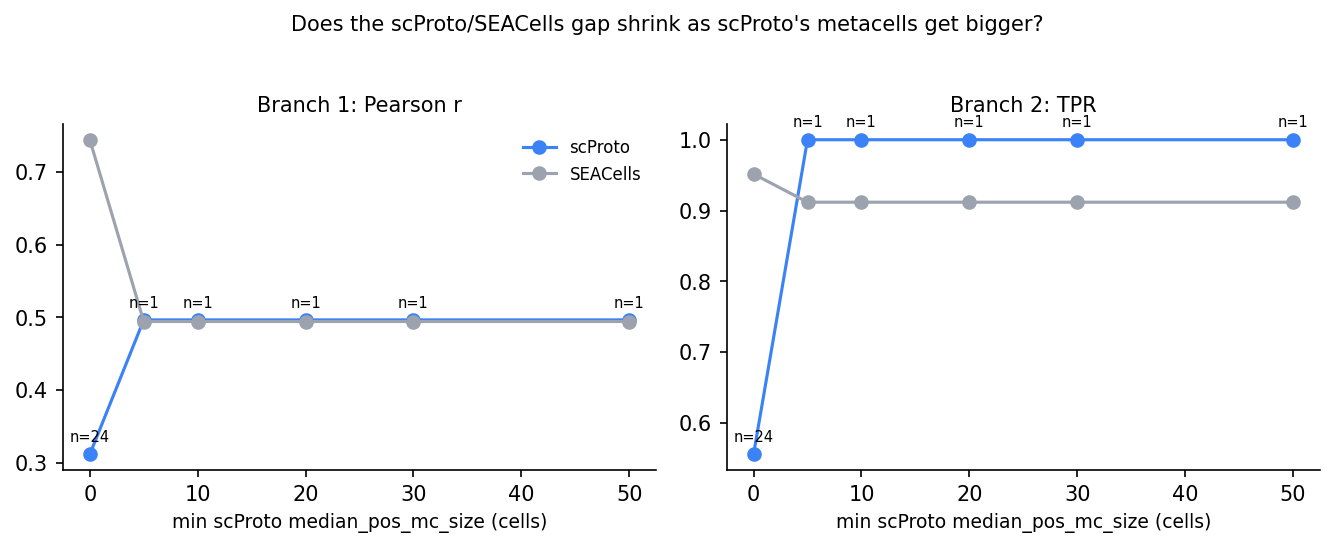

In [52]:
_sweep_colors = {'scProto': '#3B82F6', 'SEACells': '#9CA3AF'}  # kept local -- defined again below in Reporting

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
for ax, metric, title in zip(axes, ['pearson_r', 'tpr'], ['Branch 1: Pearson r', 'Branch 2: TPR']):
    ax.plot(sweep['floor'], sweep[f'scProto_{metric}'], marker='o',
            color=_sweep_colors['scProto'], label='scProto')
    ax.plot(sweep['floor'], sweep[f'SEACells_{metric}'], marker='o',
            color=_sweep_colors['SEACells'], label='SEACells')
    for _, row in sweep.iterrows():
        ax.annotate(f"n={row['n_pairs']:.0f}", (row['floor'], row[f'scProto_{metric}']),
                    fontsize=7, textcoords='offset points', xytext=(0, 6), ha='center')
    ax.set_xlabel('min scProto median_pos_mc_size (cells)', fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Does the scProto/SEACells gap shrink as scProto's metacells get bigger?", y=1.03, fontsize=10)
fig.tight_layout()
plt.show()

In [53]:
DETAIL_FLOOR = 10  # cells; illustrative single cutoff, shown alongside the sweep above

detail = combined[combined['median_pos_mc_size_scProto'] >= DETAIL_FLOOR].copy()
print(f"{len(detail)}/{len(combined)} pairs have scProto median_pos_mc_size >= {DETAIL_FLOOR}\n")

if detail.empty:
    print('No pairs clear this floor at this K -- scProto never produces a well-powered '
          'niche-positive pseudobulk at this size on this run. Read the floor=0 sweep row '
          'above as the honest baseline instead.')
else:
    cols = [
        'cell_type', 'niche',
        'median_pos_mc_size_scProto', 'median_pos_mc_size_SEACells',
        'pearson_r_scProto', 'pearson_r_SEACells',
        'tpr_scProto', 'tpr_SEACells',
    ]
    print(detail[cols].to_string(index=False))

1/24 pairs have scProto median_pos_mc_size >= 10

  cell_type           niche  median_pos_mc_size_scProto  median_pos_mc_size_SEACells  pearson_r_scProto  pearson_r_SEACells  tpr_scProto  tpr_SEACells
Fibroblasts Vascular stroma                      1776.5                         75.5           0.496472            0.494252          1.0      0.911765


**Reading this diagnostic**: the `floor=0` row of the sweep is the same full-sample result
already reported above (SEACells ahead on every metric). Watch whether `scProto_pearson_r` /
`scProto_tpr` rise toward `SEACells_pearson_r` / `SEACells_tpr` as the floor increases, even as
`n_pairs` shrinks.

- A rising trend that closes most of the gap supports re-reading plan1's verdict as "small-N
  pseudobulk noise, not absent signal" — worth then deciding whether to (a) report a caveated
  size-matched result, or (b) treat this as motivation for retraining with fewer prototypes or
  cross-cell-type edges dropped from the affinity graph (discussed earlier) before drawing a
  final conclusion.
- A flat or still-large gap even at floor=30-50 argues the opposite — that scProto's
  disadvantage isn't just a metacell-size artifact, and the earlier "smoothed spatial affinity
  teaches a coarse regional classifier instead of fine within-cell-type signal" explanation is
  more likely the real driver.

## Reporting — both branches together

In [54]:
report = branch1_summary.join(branch2_summary)
report.index.name = 'method'
print(report.round(3).to_string())

          pearson_r  kendall_tau    tpr
method                                 
scProto       0.291        0.205  0.545
SEACells      0.756        0.518  0.955


In [55]:
scp, sea = report.loc['scProto'], report.loc['SEACells']
med_mc = int(pd.concat([
    branch1['scProto']['n_pos_mc'], branch1['scProto']['n_ctrl_mc'],
]).median()) if not branch1['scProto'].empty else float('nan')

print(
    f"Using MetaQ's continuous recovery metric (logFC correlation + rank consistency, no "
    f"significance gate needed), scProto shows Pearson r={scp['pearson_r']:.3f}, Kendall "
    f"tau={scp['kendall_tau']:.3f} (SEACells-on-PCA: r={sea['pearson_r']:.3f}, "
    f"tau={sea['kendall_tau']:.3f}).\n"
    f"Using the stricter SuperCell significance-gated overlap test, TPR is "
    f"{scp['tpr']:.3f} for scProto vs {sea['tpr']:.3f} for SEACells-on-PCA — lower, as "
    f"expected, since SuperCell's test was validated on far larger per-group metacell "
    f"counts than ours (median {med_mc} metacells per group here)."
)

Using MetaQ's continuous recovery metric (logFC correlation + rank consistency, no significance gate needed), scProto shows Pearson r=0.291, Kendall tau=0.205 (SEACells-on-PCA: r=0.756, tau=0.518).
Using the stricter SuperCell significance-gated overlap test, TPR is 0.545 for scProto vs 0.955 for SEACells-on-PCA — lower, as expected, since SuperCell's test was validated on far larger per-group metacell counts than ours (median 16 metacells per group here).


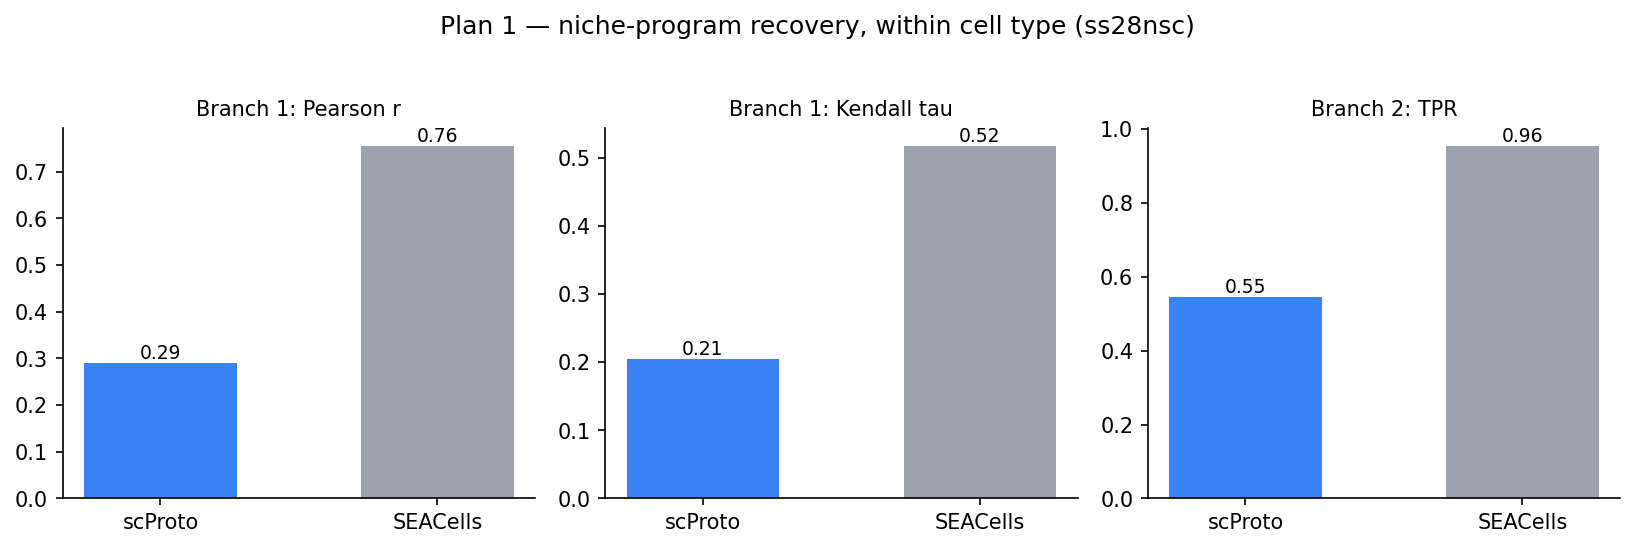

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
colors = {'scProto': '#3B82F6', 'SEACells': '#9CA3AF'}  # scProto = accent, baseline = neutral gray

for ax, metric, title in zip(
    axes, ['pearson_r', 'kendall_tau', 'tpr'],
    ['Branch 1: Pearson r', 'Branch 1: Kendall tau', 'Branch 2: TPR'],
):
    vals = report[metric]
    ax.bar(vals.index, vals.values, color=[colors[m] for m in vals.index], width=0.55)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(bottom=min(0, vals.min() * 1.1))
    ax.spines[['top', 'right']].set_visible(False)
    for i, v in enumerate(vals.values):
        ax.text(i, v, f'{v:.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=9)

fig.suptitle(f'Plan 1 — niche-program recovery, within cell type ({DS_ID})', y=1.03)
fig.tight_layout()
plt.show()

## (Optional / backup) GSEA / pathway concordance

Secondary evidence per plan1: even where individual genes don't match exactly, check whether
single-cell-level and metacell-level gene lists point to the same enriched pathways. Requires
`gseapy` + a gene-set library (needs internet access for MSigDB download in a Colab runtime) —
kept optional/best-effort so the rest of the notebook runs without it.

In [57]:
try:
    import gseapy as gp

    GENE_SET = 'MSigDB_Hallmark_2020'
    pathway_rows = []
    for (ct, niche), gt_df in ground_truth.items():
        sc_genes = gt_df.loc[gt_df['pvals_adj'] < 0.05, 'names'].head(GT_MAX_GENES).tolist()
        if len(sc_genes) < 5:
            continue
        try:
            enr = gp.enrich(gene_list=sc_genes, gene_sets=GENE_SET, outdir=None)
            top_pathways = set(enr.results.sort_values('Adjusted P-value').head(10)['Term'])
        except Exception:
            continue
        pathway_rows.append({'cell_type': ct, 'niche': niche, 'top_pathways': top_pathways})
    print(f'Computed single-cell-level top pathways for {len(pathway_rows)} (cell type, niche) pairs.')
    print('Extend this cell to run the same enrichment on each method\'s metacell-level gene '
          'list (branch1_recovery\'s per-pair mc_logfc ranking) and compare top_pathways overlap.')
except ImportError:
    print('gseapy not installed — skip (pip install gseapy) or run this cell manually if pathway '
          'concordance is needed for the rebuttal; not required for Branches 1-2 above.')

gseapy not installed — skip (pip install gseapy) or run this cell manually if pathway concordance is needed for the rebuttal; not required for Branches 1-2 above.


## Summary & caveats

- **Setup A** ground truth was recomputed from real single cells (not the truncated
  `files/celltype_niches.csv`), keeping the full ranked gene list per (cell type, niche) so
  Branch 1's correlation metrics have enough genes to be meaningful.
- **Setup B** majority-vote labeling reused `niche_recovery.mc_majority_label` unmodified on
  each run's real `cell_assignments.csv`.
- **Setup C** pseudobulk was rebuilt from real per-cell raw counts for *both* methods
  identically (not from either method's saved `.h5ad`, since scProto's is decoder-reconstructed
  — see the top-of-notebook note) — the spot-check correlation above should be close to 1.0 for
  both if raw-count aggregation held.
- **Branch 1** (primary, no significance gate) is the headline number.
- **Branch 2** (secondary) is reported alongside, expected lower — small per-(cell type, niche)
  metacell counts here (often 3-5) are below SuperCell's own validation regime.
- **Niche silhouette was intentionally not computed here** — plan1 flags it as unreliable
  evidence for this exact multi-group, non-convex setup (Rautenstrauch & Ohler, bioRxiv 2025).
- GSEA/pathway concordance is stubbed as optional/backup evidence, not required for the
  primary claim.
